In [1]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import readrbdata

In [2]:
#plot settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}"
})
plt.rcParams["font.size"] = 15

['saturated magnet signal_gen', 'saturated magnet fabry_perot', 'saturated magnet data', 'saturated no_magnet signal_gen', 'saturated no_magnet fabry_perot', 'saturated no_magnet data', 'unsaturated magnet signal_gen', 'unsaturated magnet fabry_perot', 'unsaturated magnet data', 'unsaturated no_magnet signal_gen', 'unsaturated no_magnet fabry_perot', 'unsaturated no_magnet data']


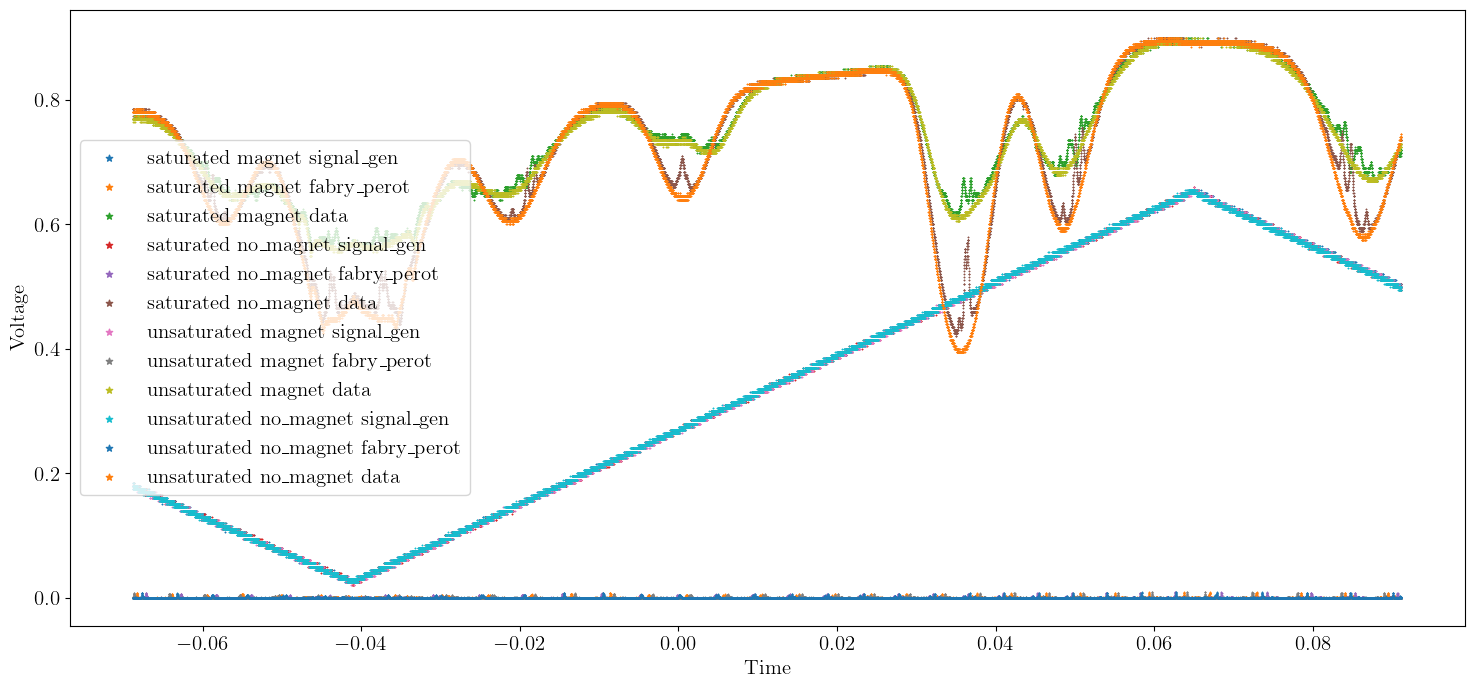

In [ ]:
# # Load in all the data
name_dict = {
    "sat":{
        "mag":{
            "scan": "SatMagCh1Scan",
            "fabry": "SatMagCh2FabryPerot",
            "signal": "SatMagCh4Signal"
        },
        "nomag":{
            "scan": "SatCh1Scan",
            "fabry": "SatCh2FabryPerot",
            "signal": "SatCh4Signal"
        }
    },
    "unsat":{
        "mag":{
            "scan": "UnSatMagCh1Scan",
            "fabry": "UnSatMagCh2FabryPerot",
            "signal": "UnSatMagCh4Signal"
        },
        "nomag":{
            "scan": "UnSatCh1Scan",
            "fabry": "UnSatCh2FabryPerot",
            "signal": "UnSatCh4Signal"
        }
    }
}


plt.figure(figsize=(18,8))
plt.xlabel("Time")
plt.ylabel("Voltage")
names=[]
frames = []
data_dict = {}
for sat_type in ["saturated", "unsaturated"]:
    data_dict[sat_type]={}
    for mag_stat in ["magnet", "no_magnet"]:
        data_dict[sat_type][mag_stat]={}
        for dat_type in ["signal_gen", "fabry_perot", "data"]:
            filename = f"./data/{sat_type}/{mag_stat}/{dat_type}.CSV"
            names.append(f"{sat_type} {mag_stat} {dat_type}")
            # print("\t\t", scan_name, filename + ".CSV")
            df = pd.read_csv(filename, skiprows=15)
            data_dict[sat_type][mag_stat][dat_type]=df
print(names)
plt.legend(names, markerscale=15)

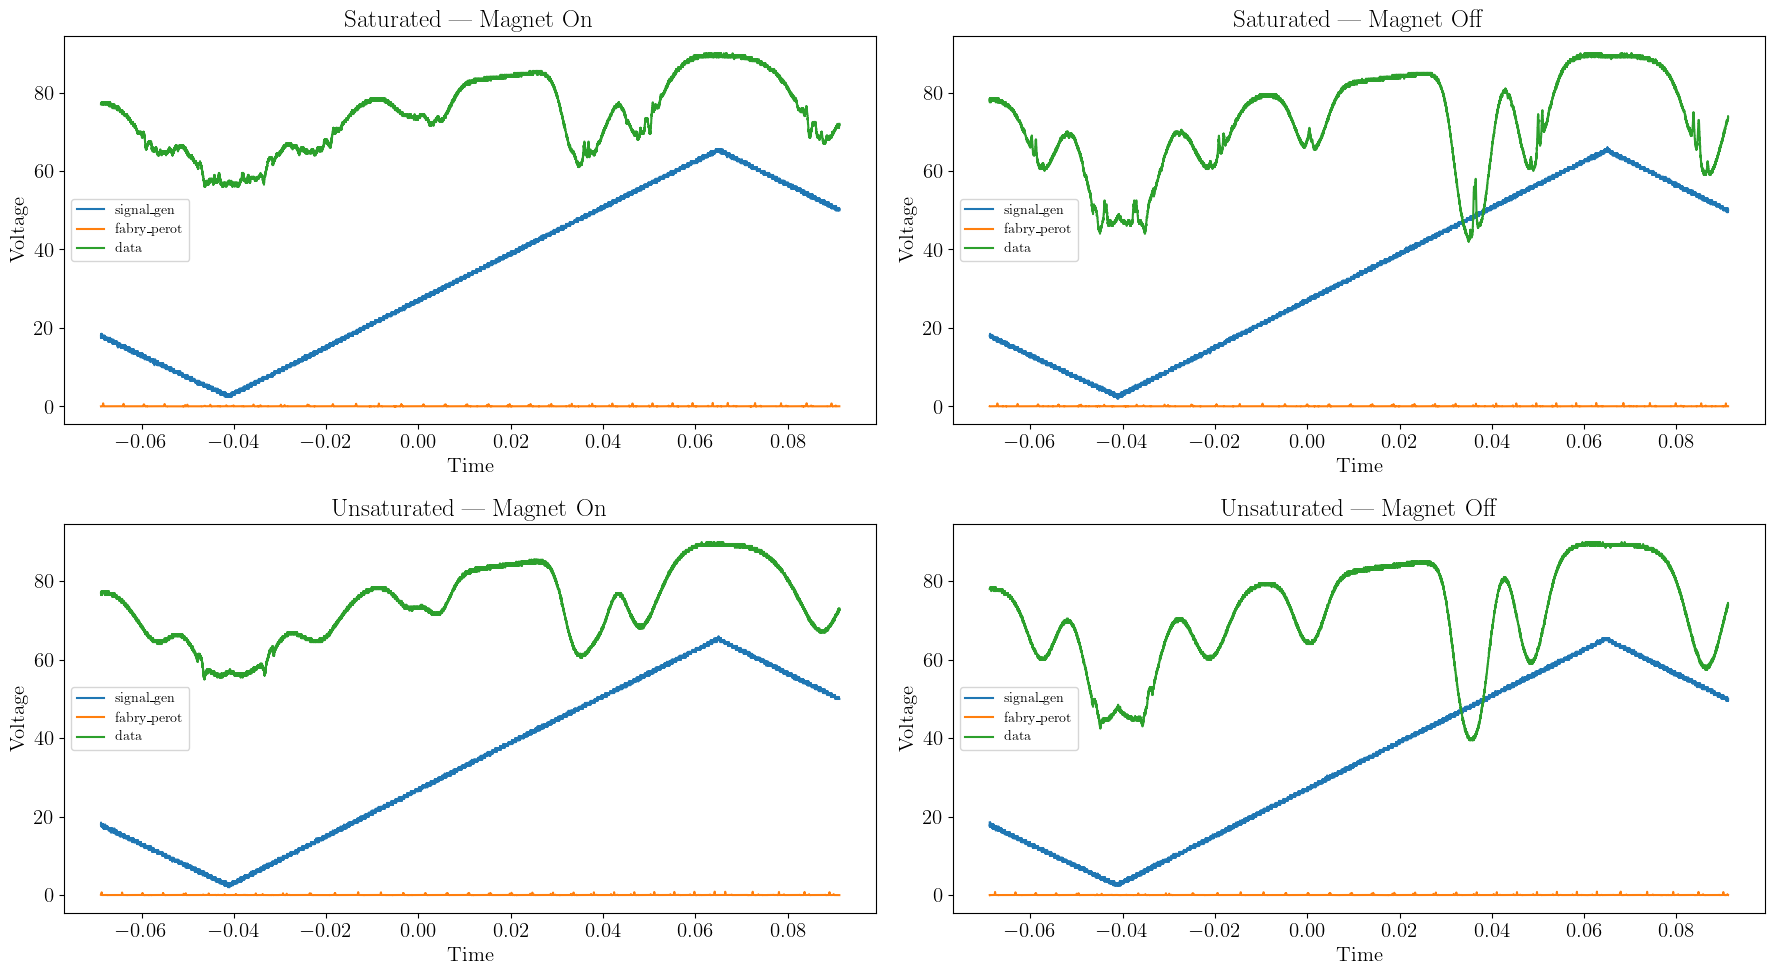

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()  # easier indexing

subplot_idx = 0

for sat_type in data_dict.keys():
    for mag_stat in data_dict[sat_type].keys():
        ax = axes[subplot_idx]
        for dat_type in data_dict[sat_type][mag_stat].keys():
            df = data_dict[sat_type][mag_stat][dat_type]
            # assuming columns are named 'time' and 'signal'
            ax.plot(df.iloc[:, 0], df.iloc[:, 1], label=dat_type)
        
        ax.set_title(f"{sat_type.capitalize()} | {"Magnet On" if mag_stat=="magnet" else "Magnet Off"}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Voltage")
        ax.legend(fontsize=10)
        
        subplot_idx += 1

plt.tight_layout()
plt.show()
plt.savefig("DataSummary.png")

The signal is repeated when it goes down / up around $t=-.04$ and $t=.07$. The first step is to cut off this repetition (at the same point for each graph). This can be done by finding the indices of signal_gen's max / min, and then cutting off before the minimum, and after tha maximum.

In [ ]:
# Use np.argmin, np.argmax, and then cut dataframes, save to truncated data.



Text(0.5, 0, 'Time')

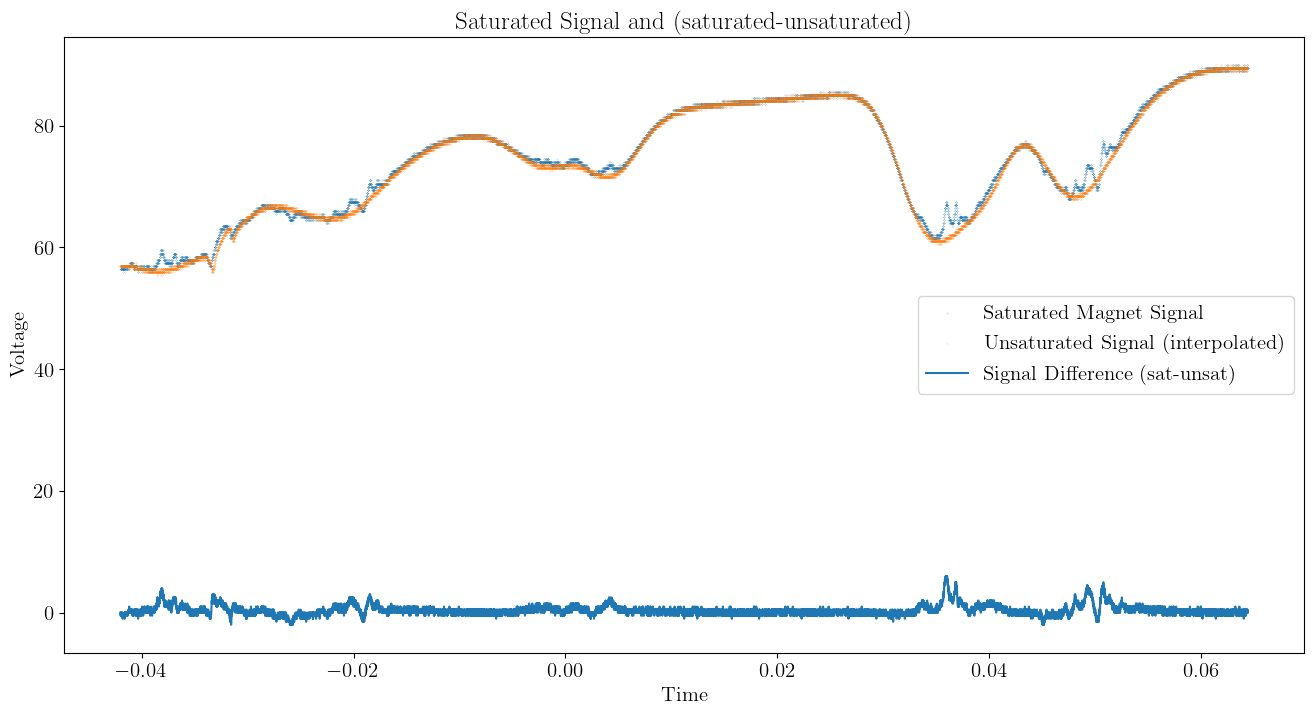

In [7]:
div=.01
satmag = readrbdata.load(sat=True, mag=True)
unsatmag = readrbdata.load(sat=False, mag=True)

uns_interp = np.interp(satmag.time, unsatmag.time, unsatmag.signal)
fig, ax = plt.subplots(figsize=(16,8))
ax.scatter(satmag.time, satmag.signal, label="Saturated Magnet Signal", s=.01)
ax.scatter(satmag.time, uns_interp, label="Unsaturated Signal (interpolated)", s=.01)
ax.plot(satmag.time, satmag.signal - uns_interp, label="Signal Difference (sat-unsat)")
ax.set_title("Saturated Signal and (saturated-unsaturated)")
ax.legend()
ax.set_ylabel("Voltage")
ax.set_xlabel("Time")

# plt.figure(figsize=(16,8))
# plt.scatter(satmag.time, np.asarray(satmag.signal)*div, s=.1)
# plt.scatter(unsatmag.time, np.asarray(unsatmag.signal)*div, s=.1)
# plt.legend(["Saturated Magnet", "Unsaturated Magnet"], markerscale=15)


In [14]:
def find_turning_points(vals: np.ndarray, nearest_k: int) -> np.ndarray:
    """
    Return indices i where the sum over the symmetric window
    vals[i-k : i+k+1] is a local minimum.

    A valid center i must have k neighbors on both sides, so only
    indices in [k, len(vals)-k-1] are considered.

    Parameters
    ----------
    vals : np.ndarray
        1D input array.
    nearest_k : int
        Number of neighbors on each side of the center.

    Returns
    -------
    np.ndarray
        Indices in the original array whose symmetric-window sums
        are local minima.
    """
    vals = np.asarray(vals)

    if vals.ndim != 1:
        raise ValueError("vals must be a 1D array")
    if nearest_k < 0:
        raise ValueError("nearest_k must be >= 0")

    n = len(vals)
    window_size = 2 * nearest_k + 1

    if n < window_size:
        return np.array([], dtype=int)

    # Rolling sums for windows centered at indices nearest_k ... n-nearest_k-1
    window_sums = np.convolve(vals, np.ones(window_size, dtype=vals.dtype), mode="valid")

    # Special case: k=0 means just find local minima of vals itself
    if len(window_sums) < 3:
        return np.array([], dtype=int)

    # Local minimum in the rolling sums
    is_local_min = (window_sums[1:-1] < window_sums[:-2]) & (window_sums[1:-1] < window_sums[2:])

    # Map back to original indices
    turning_points = np.where(is_local_min)[0] + nearest_k + 1

    return turning_points

def absorption_model(x, x0, a, b, c, d):
    return a * np.exp(-b * (x - x0)**2) + c * x + d


print(absorption_model(1.5, 1, 1, 1, 0, 0))

0.7788007830714049


p0: [np.float64(0.035112), np.float64(-42.5), 1.037235, 0.1, 85]
Fitted parameters:
x0 = 0.035535908706402955
a  = -53.0363485947342
b  = 37235.5704005172
c  = -1.524930484157639
d  = 91.90507107518854
[[ 2.71737953e-11 -4.38849440e-08 -5.30499173e-05  4.24787727e-05
  -1.46304270e-06]
 [-4.38849440e-08  2.17645401e-02  2.88328877e+01 -9.73774328e-02
  -1.96262187e-02]
 [-5.30499173e-05  2.88328877e+01  4.47975564e+04 -1.17711470e+02
  -2.85336766e+01]
 [ 4.24787727e-05 -9.73774328e-02 -1.17711470e+02  8.16844418e+01
  -2.79959730e+00]
 [-1.46304270e-06 -1.96262187e-02 -2.85336766e+01 -2.79959730e+00
   1.21234194e-01]]


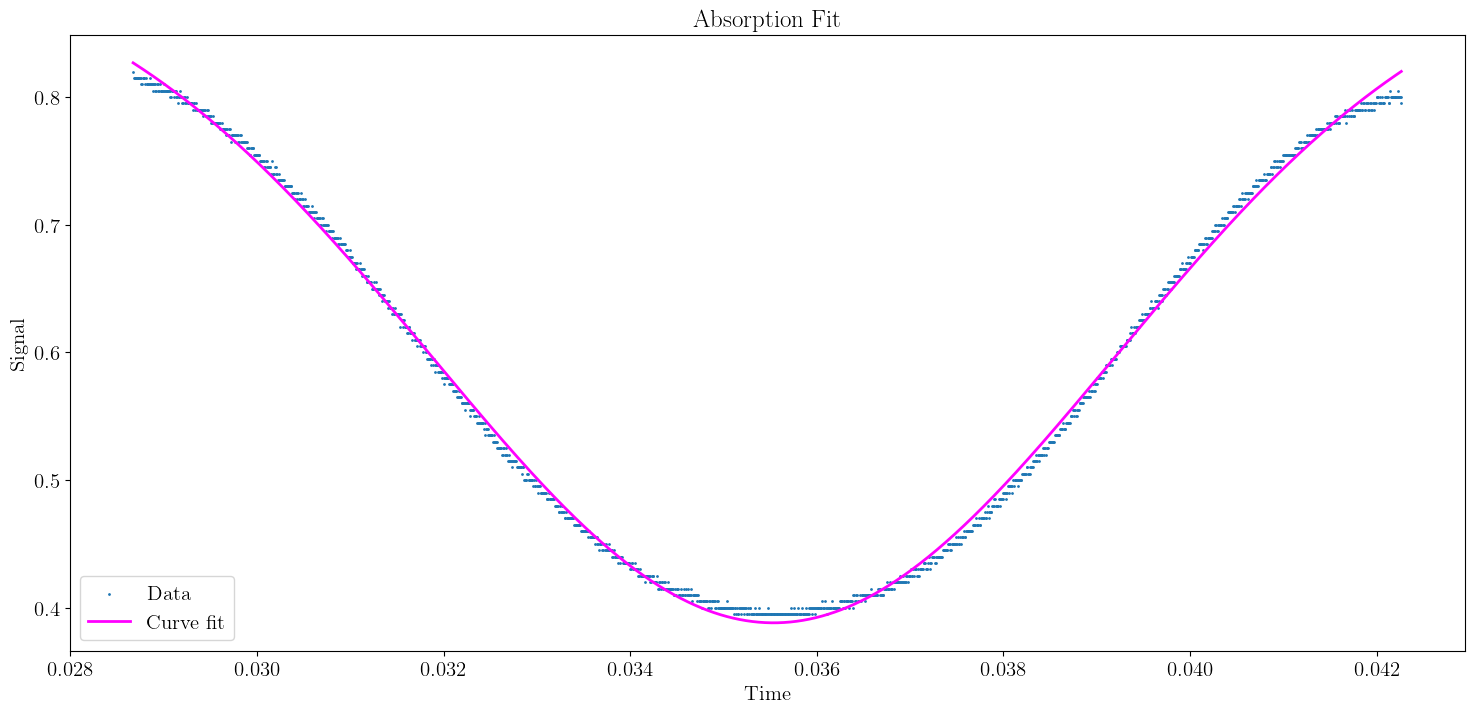

In [21]:
unsat = readrbdata.load(sat=False, mag=False)
tps = find_turning_points(unsat.signal, 20)
tps_times = np.asarray([unsat.time[tp_index] for tp_index in tps])
tps_vals = np.asarray([unsat.signal[tp_index] for tp_index in tps])

window_center=9690
window_size=1700
start=window_center- int (window_size/2)
stop=window_center+ int (window_size/2)


xdata = unsat.time[start:stop]
ydata = unsat.signal[start:stop]

#  model: a * np.exp(-b * (x - x0)**2) + c * x + d

# initial guesses
x0_guess = xdata[np.argmin(ydata)]   # center at minimum
a_guess = np.min(ydata) - np.max(ydata)   # negative dip amplitude
b_guess = 1.037235
c_guess = 0.1
d_guess = 85 # np.max(ydata)

p0 = [x0_guess, a_guess, b_guess, c_guess, d_guess]
print(f"p0: {p0}")
# optional bounds
bounds = (
    [xdata.min(), -np.inf, 0, -np.inf, -np.inf],   # lower
    [xdata.max(), 0,      np.inf, np.inf,  np.inf] # upper
)

popt, pcov = scipy.optimize.curve_fit(
    absorption_model,
    xdata,
    ydata,
    p0=p0,
    bounds=bounds,
    maxfev=10000
)

# fitted parameters
x0_fit, a_fit, b_fit, c_fit, d_fit = popt
print("Fitted parameters:")
print(f"x0 = {x0_fit}")
print(f"a  = {a_fit}")
print(f"b  = {b_fit}")
print(f"c  = {c_fit}")
print(f"d  = {d_fit}")

print(pcov)

# fitted curve
xfit = np.linspace(xdata.min(), xdata.max(), 2000)
yfit = absorption_model(xfit, *popt)

plt.figure(figsize=(18, 8))
plt.scatter(xdata, ydata*.01, s=1, label="Data")
plt.plot(xfit, yfit * .01, linewidth=2, label="Curve fit", c="magenta")
plt.xlabel("Time")
plt.ylabel("Signal")
plt.title("Absorption Fit")
plt.legend()
plt.show()

# plt.figure(figsize=(18,8))
# # satnonmagsignal = data_dict['sat']['nomag']['signal']
# # unsatnonmagsignal = data_dict['unsat']['nomag']['signal']
# plt.title("Non-Saturated Absorption")
# plt.xlabel("Time")
# plt.ylabel("Voltage")
# plt.scatter(unsat.time[start:stop], (unsat.signal)[start:stop],s=.1)
# # plt.scatter(tps_times, tps_vals, s=20)


# scipy.optimize.curve_fit(absorption_model, unsat.time[start:stop], unsat.signal[start:stop], p0=[.0355, -1, 1, 0, .9])

Expect absorption to be $$g(\omega)=\frac{c}{u \omega_0 \sqrt{\pi}}\text{exp}\left(-\frac{c^2}{u^2}\left(\frac{\omega - \omega_0}{\omega_0}\right)^2\right)$$

Which means that the Transmittance would be the inverse:

$$T(\omega)=V_{0}-A\frac{c}{u \omega_0 \sqrt{\pi}}\text{exp}\left(-\frac{c^2}{u^2}\left(\frac{\omega - \omega_0}{\omega_0}\right)^2\right)$$


In [19]:

# Chamber temp
chamber_temp = 45.2
v_laser = 5
# scan freq
c=299792458
k_b=1.38065e-23
T=273.15 + chamber_temp
N_a = 6.022e23
m85_amu = 84.91
m87_amu = 86.91
m85_kg = m85_amu / (N_a*1000)
m87_kg = m87_amu / (N_a*1000)

u85 = np.sqrt(2*k_b*T / m85_kg)
u87 = np.sqrt(2*k_b*T / m87_kg)
omega_0=c/750e-9
print(f"m85_kg: {m85_kg}\nu85: {u85}\nc: {c} m/s\n")
print(f"m87_kg: {m87_kg}\nu87: {u87}\nc: {c} m/s\n")

# The width of the doppler broadened distribution is somewhere in the range of several hundred megahertz. For a resonant frequency of c/750e-9, we expect to see the absorption spectrum from c/750e-9+-560MHz (FWHM)
# This translates to frequencies of between 3.997 227 173 33e14 to 3.997 238 373 33e14 Hz. 

# freq_vals = np.linspace(c/(c/750e-9-560e6), c/(c/750e-9+560e6), 1000)

m85_kg: 1.4099966788442375e-25
u85: 249.68944193979328
c: 299792458 m/s

m87_kg: 1.4432082364662901e-25
u87: 246.7997549674793
c: 299792458 m/s



In [ ]:
# Implement  in SI units
def g_d(omega, c, u, omega_0):
    scale = (c / (u * omega_0 * np.sqrt(np.pi)))
    print(scale)
    exp_scale = -c**2/(u**2)
    #print(f"Exp scale: {exp_scale}")
    exp_val = ((omega-omega_0)/omega_0)**2
    #print(f"Exp val: {exp_val}")
    exp = np.exp(- (c**2 / u**2) * ((omega - omega_0) / omega_0)**2)
    #print(f"Exp: {exp}")
    return scale*exp
print(f"Frequency of light with wavelength 750nm: {c/750e-9:.4g} Hz")
print(g_d(c/750e-9, c, u85, omega_0))


Frequency of light with wavelength 750nm: 3.997e+14 Hz
1.6946739292358545e-09
1.694612770222251e-09


In [ ]:
# pred_abs = np.zeros_like(freq_vals)
# for i in range(len(pred_abs)):
#     pred_abs[i]=g_d(c/freq_vals[i], c, u85, omega_0)

# print(freq_vals)
# print(pred_abs)
# plt.scatter(freq_vals, pred_abs)

In [ ]:
dp_broadened = pd.read_csv("TEK00074.CSV", skiprows=15)
dp_broadened.head(20)

In [ ]:
plt.figure(figsize=(18, 6))
plt.ylabel("Volts")
plt.xlabel("Time")
plt.plot(dp_broadened["TIME"], dp_broadened["CH4"]/100)


In [ ]:
sat_abs = pd.read_csv("TEK00071.CSV", skiprows=15)
plt.figure(figsize=(18,6))
plt.xlabel("Time"); plt.ylabel("Volts")
plt.plot(sat_abs["TIME"], sat_abs["CH4"]/100)